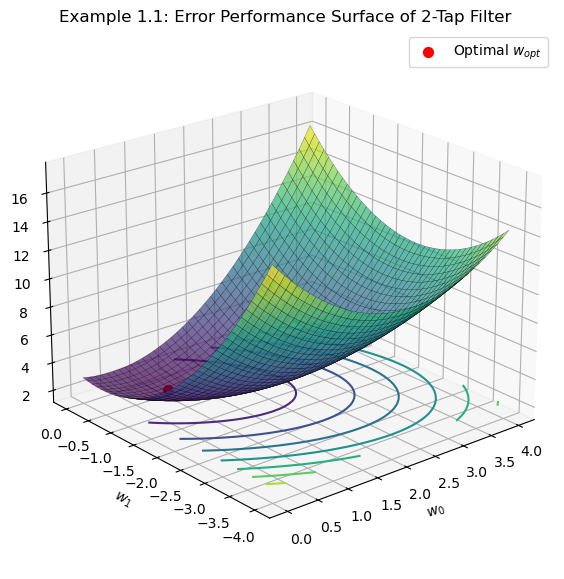

Optimal Wiener Weights (w_opt):
  w0 = 0.8363
  w1 = -0.7854
Minimum MSE (J_min): 2.2090


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Input Statistics & Parameters (Matching MATLAB exactly)
R = np.array([[1.1, 0.5], 
              [0.5, 1.1]])
p = np.array([[0.5272], 
              [-0.4458]])
dn_var = 3.0

# 2. Define grid ranges for w0 and w1
w0 = np.arange(0, 4.1, 0.1)
w1 = np.arange(-4, 0.1, 0.1)

# Create 2D meshgrid for calculation
W0, W1 = np.meshgrid(w0, w1)
J = np.zeros(W0.shape)

# 3. Compute Mean Square Error (MSE) surface J(w0, w1)
for m in range(len(w0)):
    for n in range(len(w1)):
        w = np.array([[w0[m]], [w1[n]]])
        cost = dn_var - 2 * np.dot(p.T, w) + np.dot(w.T, np.dot(R, w))
        J[n, m] = cost[0, 0]

# 4. Calculate exact Wiener optimal weights (w_opt = R^-1 * p)
w_opt = np.linalg.inv(R).dot(p)
J_min = dn_var - np.dot(p.T, w_opt)[0, 0]

# 5. Render 3D Surface and Contour Plot (meshc equivalent)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D wireframe surface
surf = ax.plot_surface(W0, W1, J, cmap='viridis', alpha=0.7, edgecolor='k', linewidth=0.2)

# Plot contour on the bottom plane (Z = min(J))
ax.contour(W0, W1, J, zdir='z', offset=np.min(J), cmap='viridis')

# Plot optimal weight marker (w_opt) on the contour floor
ax.scatter(w_opt[0, 0], w_opt[1, 0], np.min(J), color='red', s=50, marker='o', label='Optimal $w_{opt}$')

# Adjust view angle to match MATLAB view([-130 22])
ax.view_init(elev=22, azim=-130)

# Labels & Title
ax.set_xlabel('$w_0$')
ax.set_ylabel('$w_1$')
ax.set_zlabel('MSE ($J$)')
ax.set_title('Example 1.1: Error Performance Surface of 2-Tap Filter')
plt.legend()
plt.show()

# Print verified numerical values
print(f"Optimal Wiener Weights (w_opt):\n  w0 = {w_opt[0, 0]:.4f}\n  w1 = {w_opt[1, 0]:.4f}")
print(f"Minimum MSE (J_min): {J_min:.4f}")